In [4]:
import pandas as pd
df=pd.read_csv("hand/english.csv")
df.tail()

,image,label
3405,Img/img062-051.png,z
3406,Img/img062-052.png,z
3407,Img/img062-053.png,z
3408,Img/img062-054.png,z
3409,Img/img062-055.png,z


In [5]:
df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


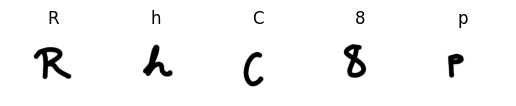

In [6]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
path="hand/"
values=random.sample(range(len(df)),5)
for i,idx in enumerate(values):
    img=os.path.join(path,df.iloc[idx]["image"])
    label=df.iloc[idx]["label"]
    image=cv2.imread(img,cv2.IMREAD_GRAYSCALE)
    plt.subplot(1,5,i+1)
    plt.imshow(image,cmap="gray")
    plt.title(label)
    plt.axis("off")
    

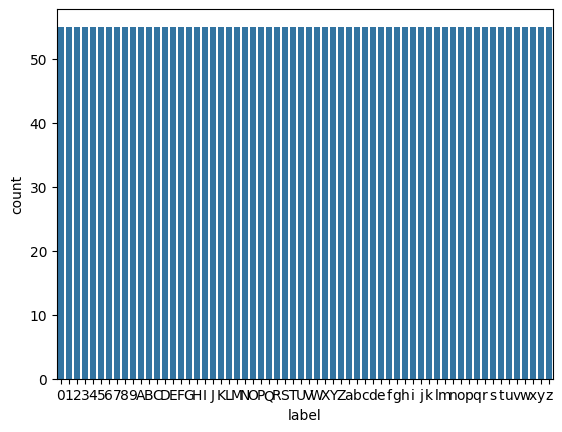

In [8]:
import seaborn as sns
sns.countplot(x="label",data=df)
plt.show()

{(900, 1200)}


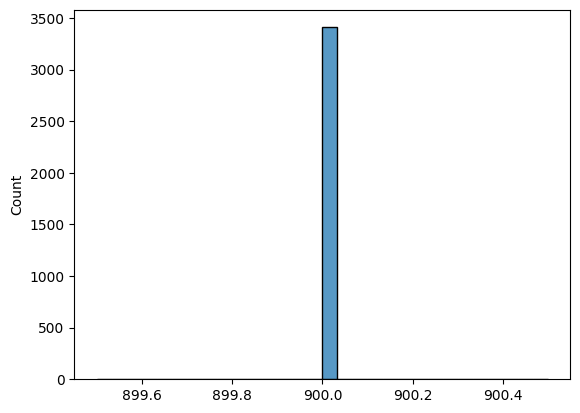

In [9]:
height=[]
weight=[]
shapes=[]
for i in range(len(df)):
    image=os.path.join(path,df.iloc[i]["image"])
    label=df.iloc[i]["label"]
    image=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    h,w=image.shape
    shapes.append(image.shape)
    height.append(h)
    weight.append(w)
print(set(shapes))
sns.histplot(height,bins=30)
plt.show()

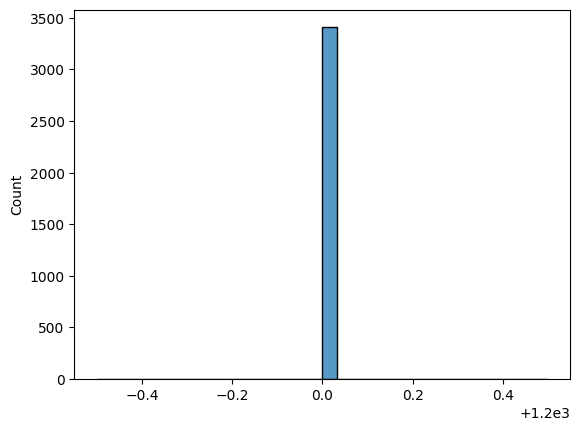

In [10]:
sns.histplot(weight,bins=30)
plt.show()

In [11]:
x=[]
y=[]
for i in range(len(df)):
    image=os.path.join(path,df.iloc[i]["image"])
    label=df.iloc[i]["label"]
    image=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    image=cv2.resize(image,(28,28))
    image=image/255.0
    image=image.flatten()
    x.append(image)
    y.append(label)

x=np.array(x)
y=np.array(y)
print(x.shape)
print(y.shape)

(3410, 784)
(3410,)


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [14]:
def step_function(i):
    return np.where(i>0,1,0)
class pla:
    def __init__(self,lr,epochs):
        self.lr=lr
        self.epochs=epochs

    def fit(self,x,y):
        self.weights=np.zeros(x.shape[1])
        self.bias=0
        self.errors=[]

        for _ in range(self.epochs):
            error=0
            for xi,yi in zip(x,y):
                i=np.dot(self.weights,xi)+self.bias
                y_hat=step_function(i)
                update=self.lr*(yi-y_hat)
                self.weights+=update*xi
                self.bias+=update
                error+=abs(update)
        self.errors.append(error)
    def score(self,x):
        return np.dot(x,self.weights)+self.bias

In [15]:
pla_models=[]
classes=np.unique(y_train)
for cls in classes:
    y_bin=np.where(y_train==cls,1,0)
    model=pla(lr=0.01,epochs=30)
    model.fit(x_train,y_bin)
    pla_models.append(model)

def pla_predict(x_test,pla_models,classes):
    scores=[]
    for i in pla_models:
        scores.append(i.score(x_test))
    best=np.argmax(scores,axis=0)
    return classes[best]
        
                      
y_pred=pla_predict(x_test,pla_models,classes)

In [16]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix
print("PLA Accuracy: ",accuracy_score(y_test,y_pred))
print("PLA Precision: ",precision_score(y_test,y_pred,average='macro'))
print("PLA Recall: ",recall_score(y_test,y_pred,average='macro'))
print("PLA F1-score: ",f1_score(y_test,y_pred,average='macro'))

PLA Accuracy:  0.14271749755620725
PLA Precision:  0.29427552027526815
PLA Recall:  0.1471846581129513
PLA F1-score:  0.13205336893020986


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


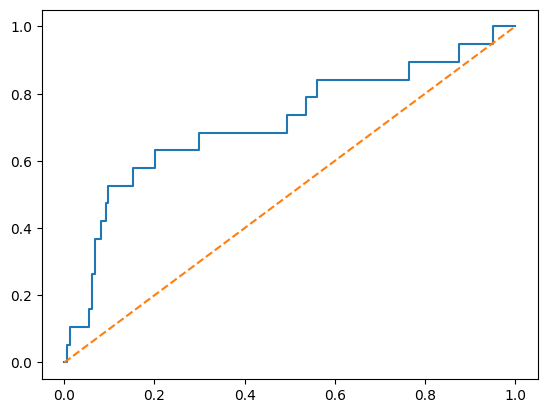

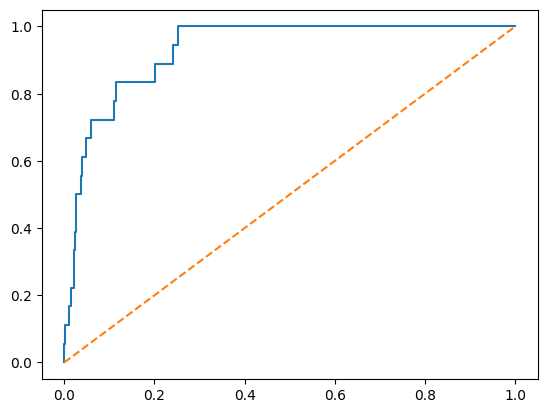

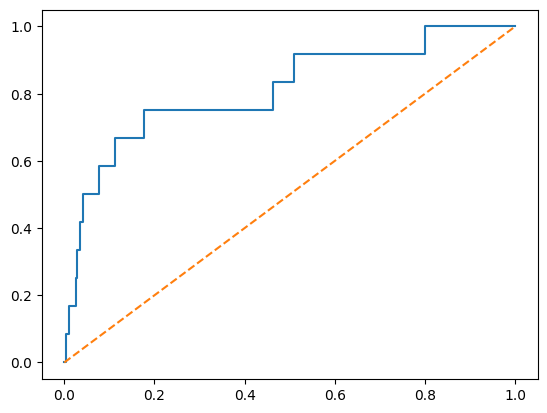

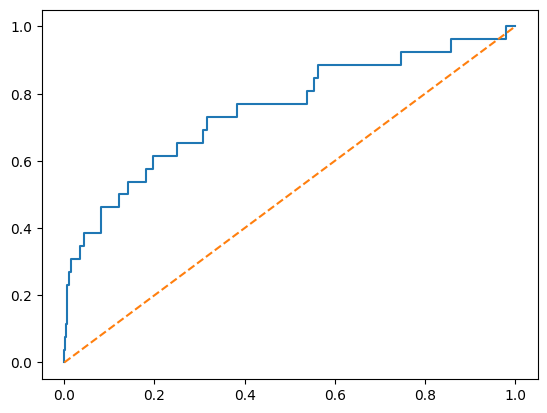

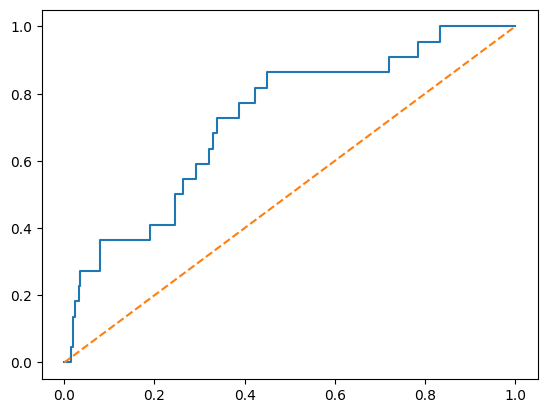

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
y_test_bin=label_binarize(y_test,classes=classes)
scores_roc=[]
for i in pla_models:
    scores_roc.append(i.score(x_test))
scores_roc=np.array(scores_roc).T
for i in range(5):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],scores_roc[:,i])
    plt.plot(fpr,tpr,label=f"Classes:{classes[i]}")
    plt.plot([0,1],[0,1],"--")
    plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(max_iter=200)

param_grid={"learning_rate_init":[0.001],"hidden_layer_sizes":[(64,32)],"activation":["relu","tanh"],"solver":["adam","sgd"],"batch_size":[32]}
grid=GridSearchCV(estimator=mlp,param_grid=param_grid,cv=5,scoring="accuracy")
grid.fit(x_train,y_train)

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

In [ ]:
best=grid.best_estimator_
y_pred=best.predict(x_test)
classes=best.classes_
y_test_bin=label_binarize(y_test,classes=classes)
print("PLA Accuracy: ",accuracy_score(y_test,y_pred))

y_pred_proba=best.predict_proba(x_test)
for i in range(2):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_pred_proba[:,i])
    plt.plot(fpr,tpr,label=f"classes:{classes[i]})
    plt.show()

